# Stream a Zarr from lincbrain.org or dandiarchive.org

Before running this code, make sure you have the required dependencies installed. You can install them using pip:
```bash
pip install 'dandi>=0.74.3' 'zarr>=3.1.5' matplotlib
```

## Import modules

In [18]:
import os
import zarr
import requests
from dandi.dandiapi import DandiAPIClient
from getpass import getpass
from matplotlib import pyplot

# Require zarr v3
if not hasattr(zarr, 'api'):
    raise ImportError(
        f"zarr v3 is required (installed: {zarr.__version__}). "
        "Run: pip install 'zarr>=3.1.5'"
    )
from zarr.api.synchronous import open_group as _zarr_open_group

## Configuration

In [19]:
# API URL (i.e. https://api.lincbrain.org/api or https://api.dandiarchive.org/api)
API_URL = "https://api.lincbrain.org/api"

# Dandiset ID and version
DANDISET_ID = "000056"
DANDISET_VERSION = "draft"

# Path to the OME-Zarr asset within the Dandiset
ASSET_PATH = "derivatives/compressed_camera1/CB1_SH2a_run100_y12_HR.ome.zarr"

In [20]:
# You will be prompted to enter your DANDI API key.  It can also be set via the DANDI_API_KEY environment variable.
DANDI_API_KEY = os.environ.get("DANDI_API_KEY")
if not DANDI_API_KEY:
    DANDI_API_KEY = getpass("Enter your DANDI API key: ")

## Retrieve the asset URL

In [21]:
with DandiAPIClient(
    api_url=API_URL,
    token=DANDI_API_KEY,
) as client:
    dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
    asset = dandiset.get_asset_by_path(ASSET_PATH)
    zarr_id = asset.zarr

print(f"Dandiset : {dandiset}")
print(f"Asset    : {asset}")
print(f"Zarr ID  : {zarr_id}")

Dandiset : LINC:000056/draft
Asset    : LINC:assets/19c0922e-ce73-4914-9c85-f3d9bcf05cc2
Zarr ID  : e86a8818-a67c-4c1d-b82e-74f589a19a39


## Open the Zarr Store

In [22]:
if "lincbrain.org" in API_URL:
    # For LINC private data, get the CloudFront signed cookies
    headers = {"Authorization": f"token {DANDI_API_KEY}"}
    session = requests.Session()
    session.get(f"{API_URL}/auth/token", headers=headers)
    response = session.get(f"{API_URL}/permissions/s3/", headers=headers)
    cookies = response.cookies.get_dict()
    cf_url = f"https://neuroglancer.lincbrain.org/zarr/{zarr_id}/"
    storage_options = {"client_kwargs": {"cookies": cookies}}
    zarr_group = _zarr_open_group(cf_url, 
                                  mode='r', 
                                  zarr_format=3, 
                                  storage_options=storage_options)
else:
    # For DANDI public data
    zarr_group = _zarr_open_group(f"s3://dandiarchive/zarr/{zarr_id}/", mode='r')

## Read the OME-Zarr metadata

In [23]:
print(zarr_group.info)

multiscales = zarr_group.attrs["multiscales"][0]
print(f"Multiscales version : {multiscales['version']}")
print(f"Axes                : {[ax['name'] for ax in multiscales['axes']]}")

for dataset in multiscales["datasets"]:
    path = dataset["path"]
    arr = zarr_group[path]
    print(f"  Level {path} — shape: {arr.shape}, dtype: {arr.dtype}, chunks: {arr.chunks}")

Name        : 
Type        : Group
Zarr format : 3
Read-only   : True
Store type  : FsspecStore
Multiscales version : 0.4
Axes                : ['z', 'y', 'x']
  Level 0 — shape: (602, 860, 133672), dtype: uint16, chunks: (256, 256, 256)
  Level 1 — shape: (301, 430, 66836), dtype: uint16, chunks: (256, 256, 256)
  Level 2 — shape: (150, 215, 33418), dtype: uint16, chunks: (256, 256, 256)
  Level 3 — shape: (75, 107, 16709), dtype: uint16, chunks: (256, 256, 256)
  Level 4 — shape: (37, 53, 8354), dtype: uint16, chunks: (256, 256, 256)
  Level 5 — shape: (18, 26, 4177), dtype: uint16, chunks: (256, 256, 256)
  Level 6 — shape: (9, 13, 2088), dtype: uint16, chunks: (256, 256, 256)
  Level 7 — shape: (4, 6, 1044), dtype: uint16, chunks: (256, 256, 256)
  Level 8 — shape: (2, 3, 522), dtype: uint16, chunks: (256, 256, 256)
  Level 9 — shape: (1, 1, 261), dtype: uint16, chunks: (256, 256, 256)
  Level 10 — shape: (1, 1, 130), dtype: uint16, chunks: (256, 256, 256)


## Create example plot

- Plot in the X-Y plane around z=300, y=300, x=68000
- Here is a similar location in [Neuroglancer](https://neuroglancer.lincbrain.org/cloudfront/frontend/index.html#!%7B%22dimensions%22:%7B%22z%22:%5B0.000001%2C%22m%22%5D%2C%22y%22:%5B0.000001%2C%22m%22%5D%2C%22x%22:%5B0.000001%2C%22m%22%5D%7D%2C%22position%22:%5B300%2C300%2C68000%5D%2C%22crossSectionScale%22:3.6825338970680646%2C%22crossSectionDepth%22:-195.1444157696926%2C%22projectionScale%22:262144%2C%22layers%22:%5B%7B%22type%22:%22image%22%2C%22source%22:%22zarr://https://neuroglancer.lincbrain.org/zarr/e86a8818-a67c-4c1d-b82e-74f589a19a39/%22%2C%22tab%22:%22rendering%22%2C%22shaderControls%22:%7B%22normalized%22:%7B%22range%22:%5B105%2C137%5D%2C%22window%22:%5B66%2C300%5D%7D%7D%2C%22name%22:%22e86a8818-a67c-4c1d-b82e-74f589a19a39%22%7D%5D%2C%22selectedLayer%22:%7B%22visible%22:true%2C%22layer%22:%22e86a8818-a67c-4c1d-b82e-74f589a19a39%22%7D%2C%22layout%22:%224panel%22%7D). This link is private to the LINC team, so if it does not load be sure to select `Get Neuroglancer Cookies` on [lincbrain.org](https://lincbrain.org/).

Level 0 shape: (602, 860, 133672)


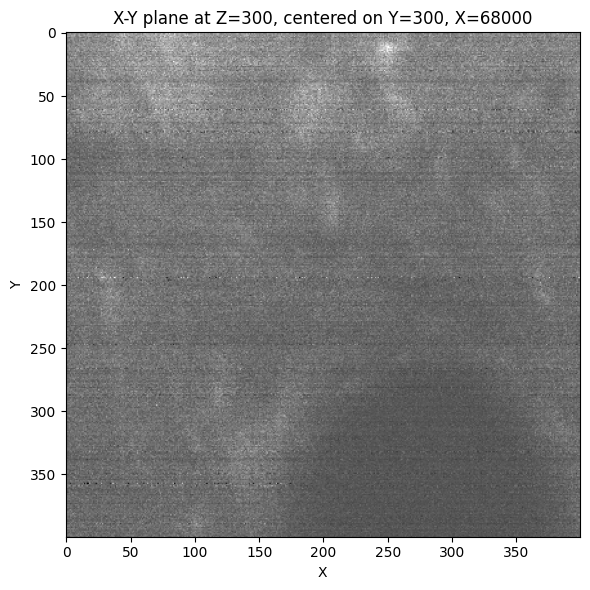

In [24]:
level0_array = zarr_group['0']
print(f"Level 0 shape: {level0_array.shape}")

z, y, x = 300, 300, 68000
width = 200
slice_xy = level0_array[z, y - width : y + width, x - width : x + width]

fig, ax = pyplot.subplots(1, 1, figsize=(6, 6))
ax.imshow(slice_xy, cmap='gray', aspect='auto')
ax.set_title(f"X-Y plane at Z={z}, centered on Y={y}, X={x}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
pyplot.tight_layout()
pyplot.show()